In [18]:
import pandas as pd
from pathlib import Path

# 1. Defining the base directory (Moving up from notebooks/python to root)
BASE_DIR = Path.cwd().parent.parent

# 2. Defining the exact path to the cleaned data
data_path = BASE_DIR / 'data' / 'cleaned' / 'trade_summary.csv'

# 3. Access file with a safety check
if not data_path.exists():
    print(f"❌ File NOT found at: {data_path}")
    print(f"Check if your folder names are 'data' and 'cleaned' (lowercase).")
else:
    # Load using the PATH object, NOT the string 'trade_summary.csv'
    df_trade = pd.read_csv(data_path)
    print("✅ File loaded successfully.")

    # 4. Clean Numeric Columns
    cols_to_fix = ['commercial_imports', 'government_imports', 'total', 
                   'domestic_fob', 're_exports', 'total_fob', 'trade_balance']

    for col in cols_to_fix:
        # We use .astype(str) to handle any unexpected numeric/NaN types before stripping commas
        df_trade[col] = df_trade[col].astype(str).str.replace(',', '').astype(float)

    # 5. Date Construction
    df_trade['date'] = pd.to_datetime(df_trade['year'].astype(str) + '-' + df_trade['month'], format='%Y-%B')
    df_trade = df_trade.set_index('date').sort_index()

    # 6. Rename columns for clarity
    df_trade = df_trade.rename(columns={
        'total': 'total_imports',
        'domestic_fob': 'domestic_exports',
        'total_fob': 'total_exports'
    })

    # 7. Feature Engineering
    df_trade['export_import_ratio'] = (df_trade['total_exports'] / df_trade['total_imports']) * 100
    df_trade['re_export_share'] = (df_trade['re_exports'] / df_trade['total_exports']) * 100

    # Preview and Save
    print(df_trade.head())
    # Save to the SAME cleaned folder or root as per your preference
    df_trade.to_csv(BASE_DIR / 'data' / 'cleaned' / 'trade_cleaned.csv')

✅ File loaded successfully.
            year      month  commercial_imports  government_imports  \
date                                                                  
1998-08-01  1998     August            14786.66              736.34   
1998-09-01  1998  September            16438.24              511.11   
1998-10-01  1998    October            16189.14              980.93   
1998-11-01  1998   November            13424.42              395.24   
1998-12-01  1998   December            17529.81              516.13   

            total_imports  domestic_exports  re_exports  total_exports  \
date                                                                     
1998-08-01       15522.99           8642.42      506.74        9149.16   
1998-09-01       16949.35           9222.37      639.03        9861.40   
1998-10-01       17170.07           9310.95      572.66        9883.61   
1998-11-01       13819.65           8633.71      455.17        9088.89   
1998-12-01       18045.94     

## External Sector Analysis. 
This phase focuses on the 'Health of the Balance of Payments' by examining how Kenya's trade relationships have evolved.
 ### Performance & Momentum

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

# 1. Setup (Using the pathlib logic we established)
BASE_DIR = Path.cwd().parent.parent
data_file = BASE_DIR / 'data' / 'cleaned' / 'trade_cleaned.csv'
df_trade = pd.read_csv(data_file, index_col='date', parse_dates=True)

# 2. Analysis: Calculating Growth Momentum
df_trade_yoy = df_trade[['total_imports', 'total_exports']].pct_change(periods=12) * 100

# 3. Analysis: Seasonal Decomposition to see the "Underlying" Deficit
# Interpolation ensures the decomposition doesn't fail on missing months
ts_decomp = df_trade['trade_balance'].interpolate(method='linear')
decomp = seasonal_decompose(ts_decomp, model='additive', period=12)

### Structural Trade Deficit
Observation: Kenya exhibits a persistent "scissors" pattern where imports grow at a steeper trajectory than exports.

Significance: A widening trade deficit exerts downward pressure on the Kenyan Shilling (KES) as more foreign currency is required to pay for imports than is earned through exports.

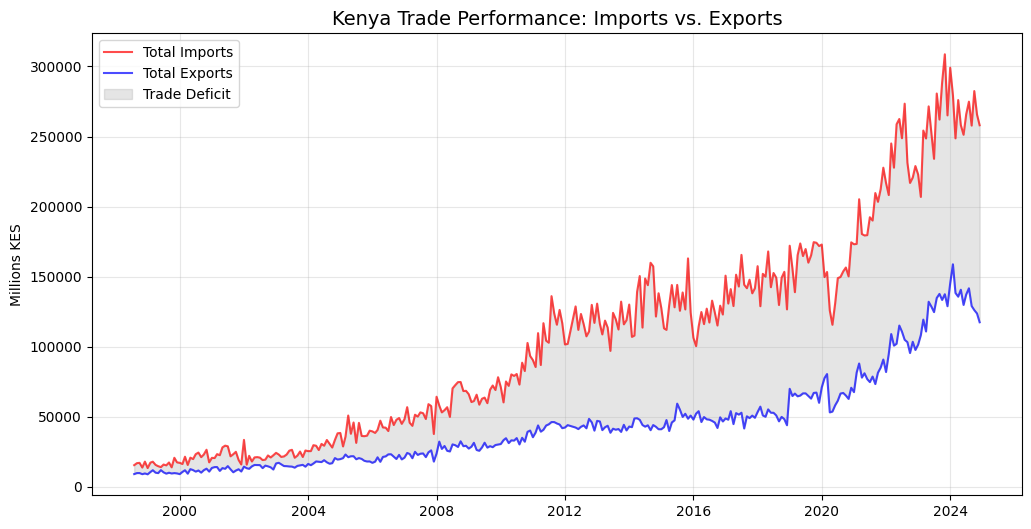

In [ ]:
# VISUALIZATION 1: Trade Performance & Coverage
plt.figure(figsize=(12, 6))
plt.plot(df_trade.index, df_trade['total_imports'], label='Total Imports', color='red', alpha=0.7)
plt.plot(df_trade.index, df_trade['total_exports'], label='Total Exports', color='blue', alpha=0.7)
plt.fill_between(df_trade.index, df_trade['total_exports'], df_trade['total_imports'], color='gray', alpha=0.2, label='Trade Deficit')
plt.title('Kenya Trade Performance: Imports vs. Exports', fontsize=14)
plt.ylabel('Millions KES')
plt.legend()
plt.grid(True, alpha=0.3)

### Export Coverage Ratio
Definition: This measures the percentage of imports funded by exported goods.

Critical Threshold: A ratio falling below 50% (as seen in recent periods) indicates that the country must rely heavily on secondary income (remittances), the capital account (FDI/Debt), or foreign reserves to maintain its consumption levels.

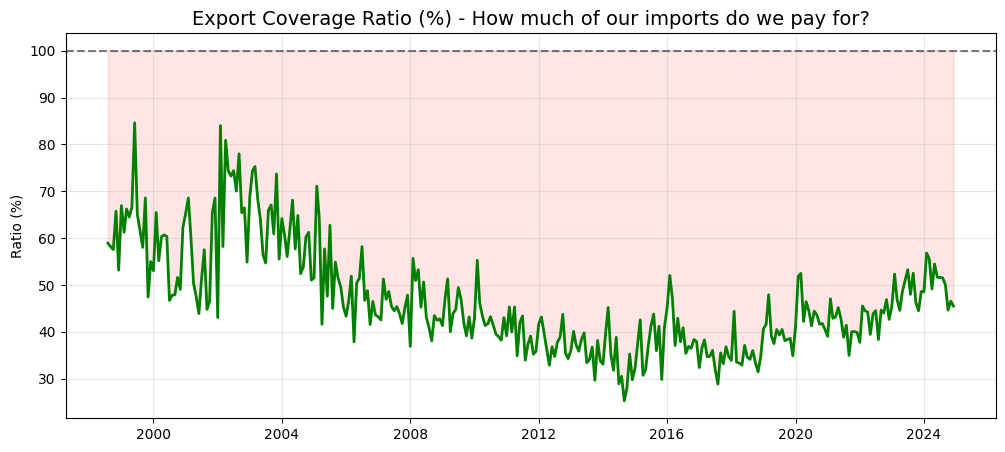

In [21]:
# VISUALIZATION 2: Coverage Ratio 
plt.figure(figsize=(12, 5))
plt.plot(df_trade.index, df_trade['export_import_ratio'], color='green', linewidth=2)
plt.axhline(100, color='black', linestyle='--', alpha=0.5, label='Balance Line')
plt.fill_between(df_trade.index, df_trade['export_import_ratio'], 100, where=(df_trade['export_import_ratio'] < 100), color='red', alpha=0.1)
plt.title('Export Coverage Ratio (%) - How much of our imports do we pay for?', fontsize=14)
plt.ylabel('Ratio (%)')
plt.grid(True, alpha=0.3)
plt.savefig('coverage_ratio.png')

### Underlying Trade Balance (Seasonally Adjusted)
To understand the structural health of Kenya's trade, we must look past the "noise" of monthly fluctuations. By applying a seasonal decomposition, we isolate the Trend, which represents the long-term direction of the trade deficit regardless of whether it's a holiday season or a harvest month.

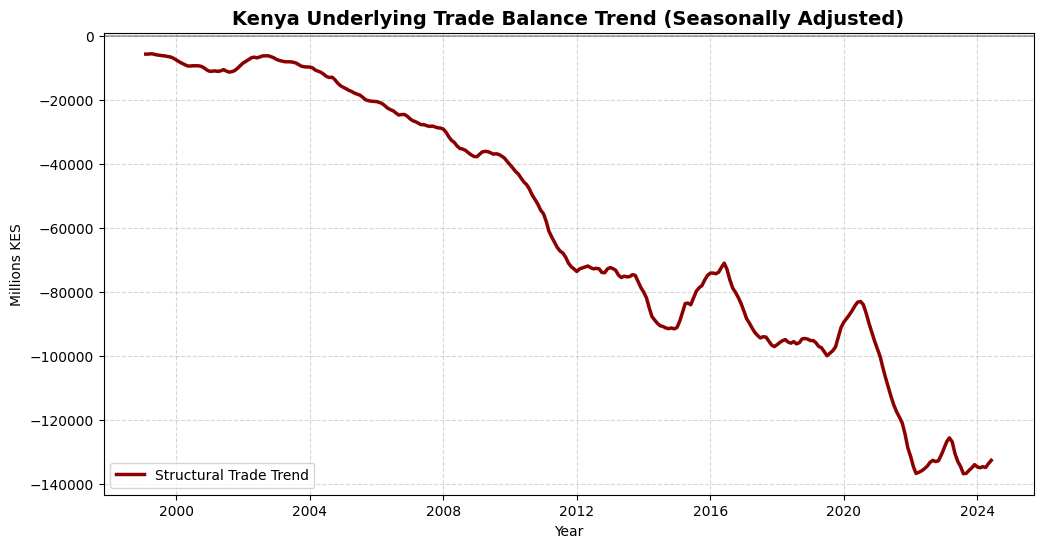

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

# 1. Path Management
BASE_DIR = Path.cwd().parent.parent
data_file = BASE_DIR / 'data' / 'cleaned' / 'trade_cleaned.csv'

# 2. Load and Prepare
df = pd.read_csv(data_file, index_col='date', parse_dates=True)

# 3. Seasonal Decomposition (Additive Model)
# We interpolate to ensure a continuous line for the math engine
ts_balance = df['trade_balance'].interpolate(method='linear')
decomposition = seasonal_decompose(ts_balance, model='additive', period=12)

# 4. Plotting the "Underlying" Trend
plt.figure(figsize=(12, 6))
plt.plot(decomposition.trend.index, decomposition.trend, 
         color='#8b0000', linewidth=2.5, label='Structural Trade Trend')

# Add a reference line at 0 (Balance)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)

# Aesthetic formatting
plt.title('Kenya Underlying Trade Balance Trend (Seasonally Adjusted)', fontsize=14, fontweight='bold')
plt.ylabel('Millions KES')
plt.xlabel('Year')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.show()

## Trend Analysis: Structural vs. Cyclical Deficits
### The "Noise" Problem: 
Raw trade data is volatile. Import spikes occur every December (festive demand), and export surges happen during tea/coffee harvest seasons.

### The Trend Discovery: 
By isolating the Underlying Trend, we observe that the trade deficit is not just fluctuating—it is structurally widening. This indicates that the growth in domestic demand for foreign goods is consistently outstripping the growth of our export production capacity.

### Policy Implication: 
If the trend line slopes downward sharply, it suggests a "Heating Up" of the economy that may lead to currency depreciation unless offset by capital inflows (like FDI or Remittances).